In [1]:
state = 'IA' 
year = 2020

In [2]:
import sys, os
src_path = os.path.abspath(os.path.join('..', '..', 'src'))
sys.path.append(src_path)

In [3]:
filepath = '../../dat/' + str(year) + '/'
filename = state + '_county.json'

In [4]:
from read import read_graph_from_json
import networkx as nx
from math import floor, ceil

G = read_graph_from_json(state, filepath + filename)
k = 4
ideal_population = sum(G.nodes[i]['TOTPOP'] for i in G.nodes) / k
L = floor( ideal_population )
U = ceil( ideal_population )

In [5]:
def check_plan(G, L, U, k, plan):
    assert len(plan) == k
    assert G.number_of_nodes() == sum( len(district) for district in plan )
    assert set(G.nodes) == { i for district in plan for i in district }
    populations = [ sum( G.nodes[i]['TOTPOP'] for i in district ) for district in plan ]
    assert L <= min(populations) and max(populations) <= U

In [6]:
def assignment(plan):
    return { i : j for j in range(len(plan)) for i in plan[j] }

def cut_edges(G, plan):
    a = assignment(plan)
    return sum( 1 for u,v in G.edges if a[u] != a[v] )

In [7]:
color = ['purple', 'red', 'blue', 'green']
initial_plan = [[0, 4, 8, 17, 43, 66, 73, 81, 93], [1, 9, 13, 14, 16, 19, 20, 21, 22, 23, 27, 30, 31, 32, 33, 35, 36, 37, 40, 41, 42, 48, 49, 50, 52, 53, 55, 57, 58, 59, 62, 63, 64, 65, 68, 70, 74, 76, 78, 79, 84, 89, 91, 92], [5, 6, 7, 10, 11, 15, 29, 34, 45, 51, 61, 69, 75, 77, 80, 85, 88, 98], [2, 3, 12, 18, 24, 25, 26, 28, 38, 39, 44, 46, 47, 54, 56, 60, 67, 71, 72, 82, 83, 86, 87, 90, 94, 95, 96, 97]]
check_plan(G, L, U, k, initial_plan)
print(f"Number of cut edges: {cut_edges(G, initial_plan)}.")

Number of cut edges: 61.


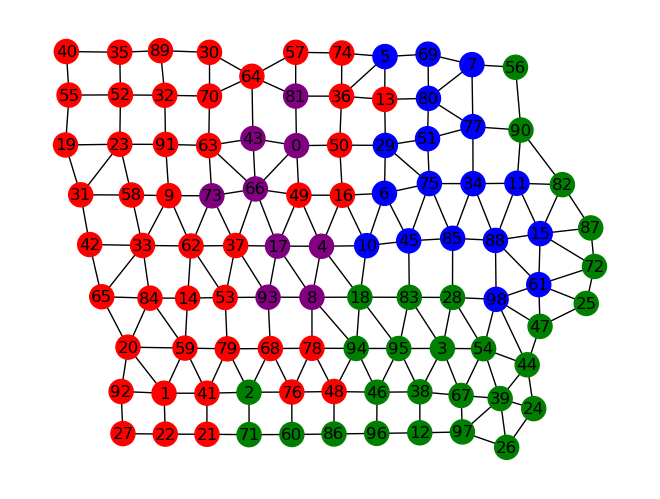

In [8]:
node_pos = { i : (float(G.nodes[i]['INTPTLON']),float(G.nodes[i]['INTPTLAT'])) for i in G.nodes }
a = assignment(initial_plan)
nx.draw(G, node_color=[ color[a[i]] for i in G.nodes], pos=node_pos, with_labels=True)

In [9]:
bipartitions = {('purple', 'red'): [[[0, 4, 8, 17, 43, 66, 73, 81, 93], [1, 9, 13, 14, 16, 19, 20, 21, 22, 23, 27, 30, 31, 32, 33, 35, 36, 37, 40, 41, 42, 48, 49, 50, 52, 53, 55, 57, 58, 59, 62, 63, 64, 65, 68, 70, 74, 76, 78, 79, 84, 89, 91, 92]], [[4, 8, 9, 37, 41, 43, 48, 49, 63, 66, 68, 76, 78, 79, 91], [0, 17, 73, 81, 93, 1, 13, 14, 16, 19, 20, 21, 22, 23, 27, 30, 31, 32, 33, 35, 36, 40, 42, 50, 52, 53, 55, 57, 58, 59, 62, 64, 65, 70, 74, 84, 89, 92]], [[0, 4, 8, 9, 17, 23, 37, 43, 58, 66, 73, 78, 91], [81, 93, 1, 13, 14, 16, 19, 20, 21, 22, 27, 30, 31, 32, 33, 35, 36, 40, 41, 42, 48, 49, 50, 52, 53, 55, 57, 59, 62, 63, 64, 65, 68, 70, 74, 76, 79, 84, 89, 92]], [[4, 8, 16, 17, 23, 37, 43, 49, 58, 62, 63, 73, 78, 91], [0, 66, 81, 93, 1, 9, 13, 14, 19, 20, 21, 22, 27, 30, 31, 32, 33, 35, 36, 40, 41, 42, 48, 50, 52, 53, 55, 57, 59, 64, 65, 68, 70, 74, 76, 79, 84, 89, 92]], [[0, 4, 8, 14, 17, 33, 48, 62, 63, 66, 70, 73, 78], [43, 81, 93, 1, 9, 13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 32, 35, 36, 37, 40, 41, 42, 49, 50, 52, 53, 55, 57, 58, 59, 64, 65, 68, 74, 76, 79, 84, 89, 91, 92]], [[4, 8, 16, 17, 33, 37, 43, 48, 53, 62, 63, 70, 73, 76, 78], [0, 66, 81, 93, 1, 9, 13, 14, 19, 20, 21, 22, 23, 27, 30, 31, 32, 35, 36, 40, 41, 42, 49, 50, 52, 55, 57, 58, 59, 64, 65, 68, 74, 79, 84, 89, 91, 92]], [[0, 4, 8, 16, 17, 33, 37, 48, 50, 58, 62, 63, 70, 73, 78], [43, 66, 81, 93, 1, 9, 13, 14, 19, 20, 21, 22, 23, 27, 30, 31, 32, 35, 36, 40, 41, 42, 49, 52, 53, 55, 57, 59, 64, 65, 68, 74, 76, 79, 84, 89, 91, 92]], [[0, 4, 8, 16, 37, 41, 48, 49, 50, 53, 59, 68, 73, 76, 78, 79, 81], [17, 43, 66, 93, 1, 9, 13, 14, 19, 20, 21, 22, 23, 27, 30, 31, 32, 33, 35, 36, 40, 42, 52, 55, 57, 58, 62, 63, 64, 65, 70, 74, 84, 89, 91, 92]], [[0, 4, 8, 17, 33, 37, 43, 48, 58, 62, 63, 68, 73, 76, 78], [66, 81, 93, 1, 9, 13, 14, 16, 19, 20, 21, 22, 23, 27, 30, 31, 32, 35, 36, 40, 41, 42, 49, 50, 52, 53, 55, 57, 59, 64, 65, 70, 74, 79, 84, 89, 91, 92]], [[1, 4, 8, 33, 37, 41, 48, 53, 59, 66, 68, 76, 78, 79, 84], [0, 17, 43, 73, 81, 93, 9, 13, 14, 16, 19, 20, 21, 22, 23, 27, 30, 31, 32, 35, 36, 40, 42, 49, 50, 52, 55, 57, 58, 62, 63, 64, 65, 70, 74, 89, 91, 92]], [[0, 4, 8, 9, 14, 33, 37, 49, 58, 62, 66, 73, 78, 81], [17, 43, 93, 1, 13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 32, 35, 36, 40, 41, 42, 48, 50, 52, 53, 55, 57, 59, 63, 64, 65, 68, 70, 74, 76, 79, 84, 89, 91, 92]], [[0, 8, 14, 17, 32, 33, 48, 49, 53, 59, 62, 63, 66, 70, 73, 78, 81, 84, 91], [4, 43, 93, 1, 9, 13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 35, 36, 37, 40, 41, 42, 50, 52, 55, 57, 58, 64, 65, 68, 74, 76, 79, 89, 92]], [[0, 1, 4, 8, 14, 33, 37, 49, 58, 59, 62, 63, 66, 78], [17, 43, 73, 81, 93, 9, 13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 32, 35, 36, 40, 41, 42, 48, 50, 52, 53, 55, 57, 64, 65, 68, 70, 74, 76, 79, 84, 89, 91, 92]], [[0, 4, 8, 17, 33, 43, 49, 59, 62, 63, 73, 78, 81, 84], [66, 93, 1, 9, 13, 14, 16, 19, 20, 21, 22, 23, 27, 30, 31, 32, 35, 36, 37, 40, 41, 42, 48, 50, 52, 53, 55, 57, 58, 64, 65, 68, 70, 74, 76, 79, 89, 91, 92]], [[4, 8, 9, 14, 21, 33, 37, 41, 48, 53, 58, 59, 62, 68, 73, 76, 78, 79], [0, 17, 43, 66, 81, 93, 1, 13, 16, 19, 20, 22, 23, 27, 30, 31, 32, 35, 36, 40, 42, 49, 50, 52, 55, 57, 63, 64, 65, 70, 74, 84, 89, 91, 92]], [[0, 8, 14, 23, 37, 53, 58, 63, 66, 70, 78, 81, 84, 91, 93], [4, 17, 43, 73, 1, 9, 13, 16, 19, 20, 21, 22, 27, 30, 31, 32, 33, 35, 36, 40, 41, 42, 48, 49, 50, 52, 55, 57, 59, 62, 64, 65, 68, 74, 76, 79, 89, 92]], [[1, 8, 14, 17, 21, 22, 23, 32, 33, 41, 48, 52, 53, 58, 59, 62, 68, 76, 78, 79, 84, 91], [0, 4, 43, 66, 73, 81, 93, 9, 13, 16, 19, 20, 27, 30, 31, 35, 36, 37, 40, 42, 49, 50, 55, 57, 63, 64, 65, 70, 74, 89, 92]], [[4, 8, 9, 16, 32, 37, 43, 49, 50, 66, 73, 78, 91], [0, 17, 81, 93, 1, 13, 14, 19, 20, 21, 22, 23, 27, 30, 31, 33, 35, 36, 40, 41, 42, 48, 52, 53, 55, 57, 58, 59, 62, 63, 64, 65, 68, 70, 74, 76, 79, 84, 89, 92]], [[0, 8, 23, 37, 48, 49, 53, 63, 66, 76, 78, 81, 91, 93], [4, 17, 43, 73, 1, 9, 13, 14, 16, 19, 20, 21, 22, 27, 30, 31, 32, 33, 35, 36, 40, 41, 42, 50, 52, 55, 57, 58, 59, 62, 64, 65, 68, 70, 74, 79, 84, 89, 92]], [[4, 8, 14, 17, 32, 33, 37, 48, 49, 62, 63, 70, 73, 76, 78], [0, 43, 66, 81, 93, 1, 9, 13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 35, 36, 40, 41, 42, 50, 52, 53, 55, 57, 58, 59, 64, 65, 68, 74, 79, 84, 89, 91, 92]], [[1, 8, 9, 14, 33, 41, 48, 59, 62, 68, 73, 76, 78, 79, 91, 93], [0, 4, 17, 43, 66, 81, 13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 32, 35, 36, 37, 40, 42, 49, 50, 52, 53, 55, 57, 58, 63, 64, 65, 70, 74, 84, 89, 92]], [[4, 8, 14, 32, 37, 43, 49, 59, 62, 63, 66, 78, 91], [0, 17, 73, 81, 93, 1, 9, 13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 33, 35, 36, 40, 41, 42, 48, 50, 52, 53, 55, 57, 58, 64, 65, 68, 70, 74, 76, 79, 84, 89, 92]], [[1, 4, 8, 9, 14, 16, 17, 33, 37, 48, 50, 58, 59, 62, 78], [0, 43, 66, 73, 81, 93, 13, 19, 20, 21, 22, 23, 27, 30, 31, 32, 35, 36, 40, 41, 42, 49, 52, 53, 55, 57, 63, 64, 65, 68, 70, 74, 76, 79, 84, 89, 91, 92]], [[0, 8, 14, 33, 37, 43, 48, 53, 58, 63, 68, 73, 76, 78, 79, 81, 84, 93], [4, 17, 66, 1, 9, 13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 32, 35, 36, 40, 41, 42, 49, 50, 52, 55, 57, 59, 62, 64, 65, 70, 74, 89, 91, 92]], [[4, 8, 9, 13, 16, 23, 36, 37, 50, 52, 53, 57, 58, 63, 64, 70, 73, 74], [0, 17, 43, 66, 81, 93, 1, 14, 19, 20, 21, 22, 27, 30, 31, 32, 33, 35, 40, 41, 42, 48, 49, 55, 59, 62, 65, 68, 76, 78, 79, 84, 89, 91, 92]], [[4, 8, 9, 21, 33, 41, 43, 48, 53, 58, 62, 63, 68, 76, 78, 79, 91], [0, 17, 66, 73, 81, 93, 1, 13, 14, 16, 19, 20, 22, 23, 27, 30, 31, 32, 35, 36, 37, 40, 42, 49, 50, 52, 55, 57, 59, 64, 65, 70, 74, 84, 89, 92]], [[0, 8, 14, 17, 32, 37, 49, 62, 63, 70, 73, 78, 91, 93], [4, 43, 66, 81, 1, 9, 13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 33, 35, 36, 40, 41, 42, 48, 50, 52, 53, 55, 57, 58, 59, 64, 65, 68, 74, 76, 79, 84, 89, 92]], [[1, 4, 8, 16, 33, 41, 48, 53, 58, 62, 63, 68, 70, 73, 76, 78, 79], [0, 17, 43, 66, 81, 93, 9, 13, 14, 19, 20, 21, 22, 23, 27, 30, 31, 32, 35, 36, 37, 40, 42, 49, 50, 52, 55, 57, 59, 64, 65, 74, 84, 89, 91, 92]], [[4, 8, 9, 14, 16, 17, 33, 37, 50, 53, 59, 62, 66, 73, 91], [0, 43, 81, 93, 1, 13, 19, 20, 21, 22, 23, 27, 30, 31, 32, 35, 36, 40, 41, 42, 48, 49, 52, 55, 57, 58, 63, 64, 65, 68, 70, 74, 76, 78, 79, 84, 89, 92]], [[8, 14, 32, 37, 43, 49, 53, 59, 63, 66, 70, 78, 91, 93], [0, 4, 17, 73, 81, 1, 9, 13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 33, 35, 36, 40, 41, 42, 48, 50, 52, 55, 57, 58, 62, 64, 65, 68, 74, 76, 79, 84, 89, 92]], [[0, 4, 8, 9, 14, 16, 17, 32, 37, 49, 50, 53, 63, 66, 70, 73, 81], [43, 93, 1, 13, 19, 20, 21, 22, 23, 27, 30, 31, 33, 35, 36, 40, 41, 42, 48, 52, 55, 57, 58, 59, 62, 64, 65, 68, 74, 76, 78, 79, 84, 89, 91, 92]], [[0, 8, 9, 14, 17, 23, 37, 49, 52, 53, 58, 62, 73, 78, 93], [4, 43, 66, 81, 1, 13, 16, 19, 20, 21, 22, 27, 30, 31, 32, 33, 35, 36, 40, 41, 42, 48, 50, 55, 57, 59, 63, 64, 65, 68, 70, 74, 76, 79, 84, 89, 91, 92]], [[8, 9, 17, 23, 48, 52, 53, 58, 62, 68, 73, 76, 78, 79, 93], [0, 4, 43, 66, 81, 1, 13, 14, 16, 19, 20, 21, 22, 27, 30, 31, 32, 33, 35, 36, 37, 40, 41, 42, 49, 50, 55, 57, 59, 63, 64, 65, 70, 74, 84, 89, 91, 92]], [[4, 8, 23, 33, 48, 49, 58, 63, 66, 70, 76, 78, 84, 91], [0, 17, 43, 73, 81, 93, 1, 9, 13, 14, 16, 19, 20, 21, 22, 27, 30, 31, 32, 35, 36, 37, 40, 41, 42, 50, 52, 53, 55, 57, 59, 62, 64, 65, 68, 74, 79, 89, 92]], [[0, 4, 8, 9, 23, 43, 48, 49, 59, 63, 68, 76, 78, 79, 84, 91], [17, 66, 73, 81, 93, 1, 13, 14, 16, 19, 20, 21, 22, 27, 30, 31, 32, 33, 35, 36, 37, 40, 41, 42, 50, 52, 53, 55, 57, 58, 62, 64, 65, 70, 74, 89, 92]], [[4, 8, 9, 14, 17, 23, 32, 37, 49, 53, 63, 73, 78, 84, 91], [0, 43, 66, 81, 93, 1, 13, 16, 19, 20, 21, 22, 27, 30, 31, 33, 35, 36, 40, 41, 42, 48, 50, 52, 55, 57, 58, 59, 62, 64, 65, 68, 70, 74, 76, 79, 89, 92]], [[4, 8, 9, 14, 32, 48, 53, 58, 62, 68, 70, 76, 78, 79, 84, 91], [0, 17, 43, 66, 73, 81, 93, 1, 13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 33, 35, 36, 37, 40, 41, 42, 49, 50, 52, 55, 57, 59, 63, 64, 65, 74, 89, 92]], [[0, 8, 17, 23, 32, 37, 49, 52, 53, 63, 70, 73, 78, 81, 93], [4, 43, 66, 1, 9, 13, 14, 16, 19, 20, 21, 22, 27, 30, 31, 33, 35, 36, 40, 41, 42, 48, 50, 55, 57, 58, 59, 62, 64, 65, 68, 74, 76, 79, 84, 89, 91, 92]], [[0, 4, 8, 21, 23, 33, 41, 48, 49, 52, 58, 59, 68, 76, 78, 79, 84], [17, 43, 66, 73, 81, 93, 1, 9, 13, 14, 16, 19, 20, 22, 27, 30, 31, 32, 35, 36, 37, 40, 42, 50, 53, 55, 57, 62, 63, 64, 65, 70, 74, 89, 91, 92]], [[4, 8, 9, 14, 16, 33, 37, 43, 49, 50, 58, 62, 63, 66, 73, 84, 91], [0, 17, 81, 93, 1, 13, 19, 20, 21, 22, 23, 27, 30, 31, 32, 35, 36, 40, 41, 42, 48, 52, 53, 55, 57, 59, 64, 65, 68, 70, 74, 76, 78, 79, 89, 92]], [[4, 8, 9, 17, 32, 33, 37, 43, 48, 52, 53, 58, 63, 70, 73, 78], [0, 66, 81, 93, 1, 13, 14, 16, 19, 20, 21, 22, 23, 27, 30, 31, 35, 36, 40, 41, 42, 49, 50, 55, 57, 59, 62, 64, 65, 68, 74, 76, 79, 84, 89, 91, 92]], [[0, 1, 4, 8, 16, 17, 33, 37, 49, 50, 58, 59, 62, 63, 70, 73, 81, 84], [43, 66, 93, 9, 13, 14, 19, 20, 21, 22, 23, 27, 30, 31, 32, 35, 36, 40, 41, 42, 48, 52, 53, 55, 57, 64, 65, 68, 74, 76, 78, 79, 89, 91, 92]], [[0, 1, 4, 8, 14, 17, 33, 49, 59, 62, 63, 66, 70, 73, 81, 84], [43, 93, 9, 13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 32, 35, 36, 37, 40, 41, 42, 48, 50, 52, 53, 55, 57, 58, 64, 65, 68, 74, 76, 78, 79, 89, 91, 92]], [[0, 4, 8, 14, 17, 23, 32, 33, 52, 58, 63, 66, 70, 73, 84, 91], [43, 81, 93, 1, 9, 13, 16, 19, 20, 21, 22, 27, 30, 31, 35, 36, 37, 40, 41, 42, 48, 49, 50, 53, 55, 57, 59, 62, 64, 65, 68, 74, 76, 78, 79, 89, 92]], [[0, 4, 8, 14, 23, 37, 43, 49, 52, 58, 62, 63, 73, 78, 81, 91], [17, 66, 93, 1, 9, 13, 16, 19, 20, 21, 22, 27, 30, 31, 32, 33, 35, 36, 40, 41, 42, 48, 50, 53, 55, 57, 59, 64, 65, 68, 70, 74, 76, 79, 84, 89, 92]], [[0, 1, 8, 14, 23, 32, 37, 49, 58, 59, 62, 63, 66, 70, 73, 91, 93], [4, 17, 43, 81, 9, 13, 16, 19, 20, 21, 22, 27, 30, 31, 33, 35, 36, 40, 41, 42, 48, 50, 52, 53, 55, 57, 64, 65, 68, 74, 76, 78, 79, 84, 89, 92]], [[0, 8, 14, 23, 32, 33, 43, 53, 58, 59, 63, 73, 78, 84, 91, 93], [4, 17, 66, 81, 1, 9, 13, 16, 19, 20, 21, 22, 27, 30, 31, 35, 36, 37, 40, 41, 42, 48, 49, 50, 52, 55, 57, 62, 64, 65, 68, 70, 74, 76, 79, 89, 92]], [[0, 1, 8, 14, 17, 23, 43, 48, 49, 53, 59, 62, 63, 66, 68, 70, 76, 78, 79, 91], [4, 73, 81, 93, 9, 13, 16, 19, 20, 21, 22, 27, 30, 31, 32, 33, 35, 36, 37, 40, 41, 42, 50, 52, 55, 57, 58, 64, 65, 74, 84, 89, 92]], [[0, 8, 14, 23, 37, 43, 49, 52, 53, 58, 63, 70, 73, 78, 81, 91, 93], [4, 17, 66, 1, 9, 13, 16, 19, 20, 21, 22, 27, 30, 31, 32, 33, 35, 36, 40, 41, 42, 48, 50, 55, 57, 59, 62, 64, 65, 68, 74, 76, 79, 84, 89, 92]], [[0, 4, 8, 17, 23, 33, 43, 52, 53, 58, 62, 63, 66, 84, 91], [73, 81, 93, 1, 9, 13, 14, 16, 19, 20, 21, 22, 27, 30, 31, 32, 35, 36, 37, 40, 41, 42, 48, 49, 50, 55, 57, 59, 64, 65, 68, 70, 74, 76, 78, 79, 89, 92]], [[0, 8, 9, 14, 17, 23, 33, 48, 49, 59, 63, 66, 68, 70, 73, 76, 78, 81, 84, 91], [4, 43, 93, 1, 13, 16, 19, 20, 21, 22, 27, 30, 31, 32, 35, 36, 37, 40, 41, 42, 50, 52, 53, 55, 57, 58, 62, 64, 65, 74, 79, 89, 92]], [[0, 8, 9, 14, 17, 23, 33, 37, 43, 48, 49, 62, 66, 68, 76, 78, 81, 84, 91], [4, 73, 93, 1, 13, 16, 19, 20, 21, 22, 27, 30, 31, 32, 35, 36, 40, 41, 42, 50, 52, 53, 55, 57, 58, 59, 63, 64, 65, 70, 74, 79, 89, 92]], [[1, 8, 9, 14, 23, 33, 48, 52, 53, 58, 59, 68, 76, 78, 79, 84, 93], [0, 4, 17, 43, 66, 73, 81, 13, 16, 19, 20, 21, 22, 27, 30, 31, 32, 35, 36, 37, 40, 41, 42, 49, 50, 55, 57, 62, 63, 64, 65, 70, 74, 89, 91, 92]], [[0, 1, 8, 14, 17, 32, 33, 37, 49, 53, 59, 62, 63, 73, 81, 91, 93], [4, 43, 66, 9, 13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 35, 36, 40, 41, 42, 48, 50, 52, 55, 57, 58, 64, 65, 68, 70, 74, 76, 78, 79, 84, 89, 92]], [[0, 1, 4, 8, 9, 14, 16, 17, 23, 37, 43, 50, 58, 59, 62, 81, 84, 91], [66, 73, 93, 13, 19, 20, 21, 22, 27, 30, 31, 32, 33, 35, 36, 40, 41, 42, 48, 49, 52, 53, 55, 57, 63, 64, 65, 68, 70, 74, 76, 78, 79, 89, 92]], [[0, 1, 8, 14, 23, 32, 37, 49, 52, 59, 62, 63, 66, 84, 91, 93], [4, 17, 43, 73, 81, 9, 13, 16, 19, 20, 21, 22, 27, 30, 31, 33, 35, 36, 40, 41, 42, 48, 50, 53, 55, 57, 58, 64, 65, 68, 70, 74, 76, 78, 79, 89, 92]], [[0, 1, 4, 8, 9, 14, 16, 33, 37, 50, 58, 59, 63, 66, 70, 73, 84, 91], [17, 43, 81, 93, 13, 19, 20, 21, 22, 23, 27, 30, 31, 32, 35, 36, 40, 41, 42, 48, 49, 52, 53, 55, 57, 62, 64, 65, 68, 74, 76, 78, 79, 89, 92]], [[0, 4, 8, 14, 17, 23, 33, 37, 52, 53, 58, 59, 62, 66, 73, 84], [43, 81, 93, 1, 9, 13, 16, 19, 20, 21, 22, 27, 30, 31, 32, 35, 36, 40, 41, 42, 48, 49, 50, 55, 57, 63, 64, 65, 68, 70, 74, 76, 78, 79, 89, 91, 92]], [[0, 4, 8, 14, 16, 32, 33, 37, 50, 52, 53, 62, 63, 66, 70, 91], [17, 43, 73, 81, 93, 1, 9, 13, 19, 20, 21, 22, 23, 27, 30, 31, 35, 36, 40, 41, 42, 48, 49, 55, 57, 58, 59, 64, 65, 68, 74, 76, 78, 79, 84, 89, 92]], [[0, 1, 8, 9, 14, 17, 23, 33, 43, 48, 49, 58, 59, 62, 66, 68, 73, 76, 78, 84], [4, 81, 93, 13, 16, 19, 20, 21, 22, 27, 30, 31, 32, 35, 36, 37, 40, 41, 42, 50, 52, 53, 55, 57, 63, 64, 65, 70, 74, 79, 89, 91, 92]], [[0, 4, 8, 9, 16, 17, 32, 33, 37, 49, 52, 62, 63, 70, 84, 91], [43, 66, 73, 81, 93, 1, 13, 14, 19, 20, 21, 22, 23, 27, 30, 31, 35, 36, 40, 41, 42, 48, 50, 53, 55, 57, 58, 59, 64, 65, 68, 74, 76, 78, 79, 89, 92]], [[0, 4, 8, 9, 14, 17, 23, 37, 43, 52, 53, 58, 59, 63, 66, 73, 81, 84], [93, 1, 13, 16, 19, 20, 21, 22, 27, 30, 31, 32, 33, 35, 36, 40, 41, 42, 48, 49, 50, 55, 57, 62, 64, 65, 68, 70, 74, 76, 78, 79, 89, 91, 92]], [[0, 4, 8, 14, 16, 23, 32, 33, 43, 49, 53, 58, 59, 62, 63, 81, 84, 91], [17, 66, 73, 93, 1, 9, 13, 19, 20, 21, 22, 27, 30, 31, 35, 36, 37, 40, 41, 42, 48, 50, 52, 55, 57, 64, 65, 68, 70, 74, 76, 78, 79, 89, 92]], [[0, 1, 8, 14, 17, 32, 37, 41, 43, 48, 49, 52, 59, 63, 66, 68, 70, 76, 78, 79, 91], [4, 73, 81, 93, 9, 13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 33, 35, 36, 40, 42, 50, 53, 55, 57, 58, 62, 64, 65, 74, 84, 89, 92]], [[1, 4, 8, 9, 14, 16, 17, 23, 33, 52, 58, 59, 63, 66, 70, 73, 84], [0, 43, 81, 93, 13, 19, 20, 21, 22, 27, 30, 31, 32, 35, 36, 37, 40, 41, 42, 48, 49, 50, 53, 55, 57, 62, 64, 65, 68, 74, 76, 78, 79, 89, 91, 92]], [[0, 4, 8, 9, 13, 14, 16, 17, 23, 36, 37, 50, 53, 58, 63, 73, 81], [43, 66, 93, 1, 19, 20, 21, 22, 27, 30, 31, 32, 33, 35, 40, 41, 42, 48, 49, 52, 55, 57, 59, 62, 64, 65, 68, 70, 74, 76, 78, 79, 84, 89, 91, 92]], [[0, 8, 14, 21, 23, 33, 37, 41, 48, 49, 53, 59, 62, 63, 66, 68, 70, 76, 78, 79, 84, 91], [4, 17, 43, 73, 81, 93, 1, 9, 13, 16, 19, 20, 22, 27, 30, 31, 32, 35, 36, 40, 42, 50, 52, 55, 57, 58, 64, 65, 74, 89, 92]], [[0, 8, 17, 21, 22, 23, 33, 41, 48, 59, 62, 63, 66, 68, 70, 73, 76, 78, 79, 91], [4, 43, 81, 93, 1, 9, 13, 14, 16, 19, 20, 27, 30, 31, 32, 35, 36, 37, 40, 42, 49, 50, 52, 53, 55, 57, 58, 64, 65, 74, 84, 89, 92]], [[0, 8, 9, 17, 21, 23, 33, 37, 41, 43, 48, 49, 58, 59, 66, 68, 76, 78, 79, 84, 91], [4, 73, 81, 93, 1, 13, 14, 16, 19, 20, 22, 27, 30, 31, 32, 35, 36, 40, 42, 50, 52, 53, 55, 57, 62, 63, 64, 65, 70, 74, 89, 92]], [[1, 8, 9, 14, 17, 23, 37, 41, 43, 48, 49, 52, 58, 59, 63, 66, 68, 70, 73, 76, 78, 79, 84], [0, 4, 81, 93, 13, 16, 19, 20, 21, 22, 27, 30, 31, 32, 33, 35, 36, 40, 42, 50, 53, 55, 57, 62, 64, 65, 74, 89, 91, 92]], [[4, 8, 13, 14, 16, 17, 23, 36, 37, 43, 50, 62, 63, 73, 91], [0, 66, 81, 93, 1, 9, 19, 20, 21, 22, 27, 30, 31, 32, 33, 35, 40, 41, 42, 48, 49, 52, 53, 55, 57, 58, 59, 64, 65, 68, 70, 74, 76, 78, 79, 84, 89, 92]], [[4, 8, 9, 14, 16, 23, 32, 49, 52, 53, 62, 63, 66, 70, 84, 91], [0, 17, 43, 73, 81, 93, 1, 13, 19, 20, 21, 22, 27, 30, 31, 33, 35, 36, 37, 40, 41, 42, 48, 50, 55, 57, 58, 59, 64, 65, 68, 74, 76, 78, 79, 89, 92]], [[0, 4, 8, 9, 13, 14, 16, 36, 37, 43, 49, 50, 53, 63, 70, 73, 81, 84], [17, 66, 93, 1, 19, 20, 21, 22, 23, 27, 30, 31, 32, 33, 35, 40, 41, 42, 48, 52, 55, 57, 58, 59, 62, 64, 65, 68, 74, 76, 78, 79, 89, 91, 92]], [[0, 8, 9, 14, 21, 32, 37, 41, 48, 49, 52, 53, 62, 63, 66, 68, 73, 76, 78, 79, 84, 91], [4, 17, 43, 81, 93, 1, 13, 16, 19, 20, 22, 23, 27, 30, 31, 33, 35, 36, 40, 42, 50, 55, 57, 58, 59, 64, 65, 70, 74, 89, 92]], [[0, 4, 8, 16, 23, 32, 33, 37, 49, 52, 53, 58, 63, 66, 84, 91], [17, 43, 73, 81, 93, 1, 9, 13, 14, 19, 20, 21, 22, 27, 30, 31, 35, 36, 40, 41, 42, 48, 50, 55, 57, 59, 62, 64, 65, 68, 70, 74, 76, 78, 79, 89, 92]], [[0, 8, 9, 14, 23, 32, 37, 48, 49, 53, 58, 59, 62, 66, 68, 70, 76, 78, 79, 84, 91], [4, 17, 43, 73, 81, 93, 1, 13, 16, 19, 20, 21, 22, 27, 30, 31, 33, 35, 36, 40, 41, 42, 50, 52, 55, 57, 63, 64, 65, 74, 89, 92]], [[0, 1, 4, 8, 9, 14, 17, 32, 43, 49, 53, 58, 59, 62, 63, 70, 84, 91], [66, 73, 81, 93, 13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 33, 35, 36, 37, 40, 41, 42, 48, 50, 52, 55, 57, 64, 65, 68, 74, 76, 78, 79, 89, 92]], [[8, 9, 17, 23, 33, 37, 41, 48, 49, 52, 58, 59, 63, 66, 68, 70, 73, 76, 78, 79, 91], [0, 4, 43, 81, 93, 1, 13, 14, 16, 19, 20, 21, 22, 27, 30, 31, 32, 35, 36, 40, 42, 50, 53, 55, 57, 62, 64, 65, 74, 84, 89, 92]], [[0, 8, 9, 23, 32, 37, 41, 48, 49, 53, 59, 62, 66, 68, 70, 73, 76, 78, 79, 81, 91], [4, 17, 43, 93, 1, 13, 14, 16, 19, 20, 21, 22, 27, 30, 31, 33, 35, 36, 40, 42, 50, 52, 55, 57, 58, 63, 64, 65, 74, 84, 89, 92]], [[0, 1, 8, 9, 17, 21, 22, 23, 33, 41, 48, 49, 53, 58, 63, 66, 68, 76, 78, 79, 91], [4, 43, 73, 81, 93, 13, 14, 16, 19, 20, 27, 30, 31, 32, 35, 36, 37, 40, 42, 50, 52, 55, 57, 59, 62, 64, 65, 70, 74, 84, 89, 92]], [[0, 8, 9, 14, 32, 33, 37, 48, 59, 62, 63, 66, 68, 70, 73, 76, 78, 79, 81, 84, 91], [4, 17, 43, 93, 1, 13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 35, 36, 40, 41, 42, 49, 50, 52, 53, 55, 57, 58, 64, 65, 74, 89, 92]], [[0, 4, 8, 9, 14, 32, 37, 43, 49, 52, 59, 62, 66, 81, 84, 91], [17, 73, 93, 1, 13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 33, 35, 36, 40, 41, 42, 48, 50, 53, 55, 57, 58, 63, 64, 65, 68, 70, 74, 76, 78, 79, 89, 92]], [[0, 1, 8, 9, 32, 33, 37, 43, 48, 49, 52, 58, 59, 63, 66, 68, 76, 78, 79, 84, 91], [4, 17, 73, 81, 93, 13, 14, 16, 19, 20, 21, 22, 23, 27, 30, 31, 35, 36, 40, 41, 42, 50, 53, 55, 57, 62, 64, 65, 70, 74, 89, 92]], [[0, 1, 8, 14, 21, 33, 41, 48, 49, 59, 62, 63, 66, 68, 70, 73, 76, 78, 79, 81, 84, 91], [4, 17, 43, 93, 9, 13, 16, 19, 20, 22, 23, 27, 30, 31, 32, 35, 36, 37, 40, 42, 50, 52, 53, 55, 57, 58, 64, 65, 74, 89, 92]], [[0, 8, 9, 21, 32, 33, 41, 43, 48, 49, 59, 62, 63, 66, 68, 73, 76, 78, 79, 84, 91], [4, 17, 81, 93, 1, 13, 14, 16, 19, 20, 22, 23, 27, 30, 31, 35, 36, 37, 40, 42, 50, 52, 53, 55, 57, 58, 64, 65, 70, 74, 89, 92]], [[0, 8, 9, 14, 23, 32, 37, 43, 49, 52, 53, 58, 63, 66, 70, 73, 91, 93], [4, 17, 81, 1, 13, 16, 19, 20, 21, 22, 27, 30, 31, 33, 35, 36, 40, 41, 42, 48, 50, 55, 57, 59, 62, 64, 65, 68, 74, 76, 78, 79, 84, 89, 92]], [[0, 1, 8, 9, 14, 17, 32, 33, 43, 49, 59, 63, 70, 73, 81, 84, 91, 93], [4, 66, 13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 35, 36, 37, 40, 41, 42, 48, 50, 52, 53, 55, 57, 58, 62, 64, 65, 68, 74, 76, 78, 79, 89, 92]], [[0, 8, 9, 14, 17, 23, 33, 43, 48, 49, 52, 53, 59, 62, 66, 73, 76, 78, 91], [4, 81, 93, 1, 13, 16, 19, 20, 21, 22, 27, 30, 31, 32, 35, 36, 37, 40, 41, 42, 50, 55, 57, 58, 63, 64, 65, 68, 70, 74, 79, 84, 89, 92]], [[0, 4, 8, 9, 14, 23, 32, 37, 43, 49, 52, 58, 62, 63, 66, 73, 91], [17, 81, 93, 1, 13, 16, 19, 20, 21, 22, 27, 30, 31, 33, 35, 36, 40, 41, 42, 48, 50, 53, 55, 57, 59, 64, 65, 68, 70, 74, 76, 78, 79, 84, 89, 92]], [[0, 1, 8, 9, 21, 22, 23, 27, 33, 37, 41, 43, 48, 53, 58, 59, 62, 66, 68, 76, 78, 79, 81], [4, 17, 73, 93, 13, 14, 16, 19, 20, 30, 31, 32, 35, 36, 40, 42, 49, 50, 52, 55, 57, 63, 64, 65, 70, 74, 84, 89, 91, 92]], [[0, 1, 8, 9, 14, 17, 23, 32, 43, 48, 49, 52, 59, 63, 66, 68, 76, 78, 79, 91], [4, 73, 81, 93, 13, 16, 19, 20, 21, 22, 27, 30, 31, 33, 35, 36, 37, 40, 41, 42, 50, 53, 55, 57, 58, 62, 64, 65, 70, 74, 84, 89, 92]], [[8, 14, 17, 21, 22, 23, 41, 48, 49, 52, 53, 58, 62, 63, 66, 68, 70, 76, 78, 79, 91], [0, 4, 43, 73, 81, 93, 1, 9, 13, 16, 19, 20, 27, 30, 31, 32, 33, 35, 36, 37, 40, 42, 50, 55, 57, 59, 64, 65, 74, 84, 89, 92]], [[0, 8, 17, 23, 37, 43, 48, 52, 58, 59, 63, 66, 68, 70, 73, 76, 78, 79, 81, 84, 91], [4, 93, 1, 9, 13, 14, 16, 19, 20, 21, 22, 27, 30, 31, 32, 33, 35, 36, 40, 41, 42, 49, 50, 53, 55, 57, 62, 64, 65, 74, 89, 92]], [[1, 8, 9, 14, 17, 21, 22, 23, 37, 41, 43, 48, 49, 59, 63, 66, 68, 73, 76, 78, 79, 91], [0, 4, 81, 93, 13, 16, 19, 20, 27, 30, 31, 32, 33, 35, 36, 40, 42, 50, 52, 53, 55, 57, 58, 62, 64, 65, 70, 74, 84, 89, 92]], [[0, 8, 9, 14, 17, 32, 33, 48, 49, 52, 53, 58, 62, 66, 70, 73, 78, 84, 91], [4, 43, 81, 93, 1, 13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 35, 36, 37, 40, 41, 42, 50, 55, 57, 59, 63, 64, 65, 68, 74, 76, 79, 89, 92]], [[1, 8, 17, 21, 22, 23, 27, 33, 37, 41, 48, 52, 58, 62, 63, 66, 68, 70, 73, 76, 78, 79], [0, 4, 43, 81, 93, 9, 13, 14, 16, 19, 20, 30, 31, 32, 35, 36, 40, 42, 49, 50, 53, 55, 57, 59, 64, 65, 74, 84, 89, 91, 92]], [[0, 1, 8, 9, 14, 21, 22, 23, 27, 41, 43, 48, 49, 58, 59, 62, 63, 66, 68, 70, 73, 76, 78, 79], [4, 17, 81, 93, 13, 16, 19, 20, 30, 31, 32, 33, 35, 36, 37, 40, 42, 50, 52, 53, 55, 57, 64, 65, 74, 84, 89, 91, 92]], [[0, 1, 8, 9, 14, 17, 32, 48, 49, 58, 59, 62, 63, 66, 70, 73, 78, 81, 84, 91], [4, 43, 93, 13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 33, 35, 36, 37, 40, 41, 42, 50, 52, 53, 55, 57, 64, 65, 68, 74, 76, 79, 89, 92]], [[0, 1, 8, 9, 21, 22, 33, 41, 43, 48, 53, 58, 59, 62, 63, 66, 68, 73, 76, 78, 79, 91], [4, 17, 81, 93, 13, 14, 16, 19, 20, 23, 27, 30, 31, 32, 35, 36, 37, 40, 42, 49, 50, 52, 55, 57, 64, 65, 70, 74, 84, 89, 92]], [[1, 8, 9, 17, 21, 22, 23, 27, 37, 41, 43, 48, 49, 59, 63, 66, 68, 70, 76, 78, 79, 91], [0, 4, 73, 81, 93, 13, 14, 16, 19, 20, 30, 31, 32, 33, 35, 36, 40, 42, 50, 52, 53, 55, 57, 58, 62, 64, 65, 74, 84, 89, 92]], [[0, 1, 8, 9, 14, 21, 22, 23, 27, 32, 37, 41, 43, 48, 49, 52, 53, 58, 66, 68, 73, 76, 78, 79], [4, 17, 81, 93, 13, 16, 19, 20, 30, 31, 33, 35, 36, 40, 42, 50, 55, 57, 59, 62, 63, 64, 65, 70, 74, 84, 89, 91, 92]], [[0, 1, 8, 9, 14, 32, 48, 49, 58, 59, 62, 66, 68, 70, 73, 76, 78, 79, 81, 84, 91], [4, 17, 43, 93, 13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 33, 35, 36, 37, 40, 41, 42, 50, 52, 53, 55, 57, 63, 64, 65, 74, 89, 92]], [[0, 8, 9, 14, 17, 21, 22, 32, 33, 41, 48, 49, 58, 59, 62, 68, 70, 76, 78, 79, 84, 91], [4, 43, 66, 73, 81, 93, 1, 13, 16, 19, 20, 23, 27, 30, 31, 35, 36, 37, 40, 42, 50, 52, 53, 55, 57, 63, 64, 65, 74, 89, 92]], [[4, 8, 9, 13, 16, 36, 37, 43, 49, 50, 57, 58, 63, 64, 73, 74, 91], [0, 17, 66, 81, 93, 1, 14, 19, 20, 21, 22, 23, 27, 30, 31, 32, 33, 35, 40, 41, 42, 48, 52, 53, 55, 59, 62, 65, 68, 70, 76, 78, 79, 84, 89, 92]], [[1, 8, 9, 17, 21, 23, 32, 33, 41, 48, 53, 58, 59, 62, 66, 68, 76, 78, 79, 91], [0, 4, 43, 73, 81, 93, 13, 14, 16, 19, 20, 22, 27, 30, 31, 35, 36, 37, 40, 42, 49, 50, 52, 55, 57, 63, 64, 65, 70, 74, 84, 89, 92]], [[0, 1, 8, 9, 21, 23, 33, 41, 48, 52, 53, 58, 59, 62, 63, 66, 68, 70, 73, 76, 78, 79, 81], [4, 17, 43, 93, 13, 14, 16, 19, 20, 22, 27, 30, 31, 32, 35, 36, 37, 40, 42, 49, 50, 55, 57, 64, 65, 74, 84, 89, 91, 92]], [[0, 1, 4, 8, 14, 16, 23, 32, 33, 37, 43, 49, 52, 58, 59, 63, 70, 73, 81, 84], [17, 66, 93, 9, 13, 19, 20, 21, 22, 27, 30, 31, 35, 36, 40, 41, 42, 48, 50, 53, 55, 57, 62, 64, 65, 68, 74, 76, 78, 79, 89, 91, 92]], [[8, 9, 21, 22, 23, 27, 33, 41, 48, 52, 53, 58, 62, 63, 66, 68, 70, 76, 78, 79, 91, 92], [0, 4, 17, 43, 73, 81, 93, 1, 13, 14, 16, 19, 20, 30, 31, 32, 35, 36, 37, 40, 42, 49, 50, 55, 57, 59, 64, 65, 74, 84, 89]], [[0, 8, 21, 22, 27, 33, 41, 43, 48, 49, 58, 59, 62, 66, 68, 73, 76, 78, 79, 81, 84, 92], [4, 17, 93, 1, 9, 13, 14, 16, 19, 20, 23, 30, 31, 32, 35, 36, 37, 40, 42, 50, 52, 53, 55, 57, 63, 64, 65, 70, 74, 89, 91]], [[0, 1, 8, 14, 21, 22, 33, 41, 48, 53, 59, 62, 63, 66, 68, 70, 73, 76, 78, 79, 84, 91], [4, 17, 43, 81, 93, 9, 13, 16, 19, 20, 23, 27, 30, 31, 32, 35, 36, 37, 40, 42, 49, 50, 52, 55, 57, 58, 64, 65, 74, 89, 92]], [[0, 8, 9, 14, 21, 23, 37, 41, 43, 48, 52, 53, 58, 59, 63, 66, 68, 73, 76, 78, 79, 81, 84, 91], [4, 17, 93, 1, 13, 16, 19, 20, 22, 27, 30, 31, 32, 33, 35, 36, 40, 42, 49, 50, 55, 57, 62, 64, 65, 70, 74, 89, 92]], [[0, 1, 8, 9, 17, 21, 23, 32, 33, 37, 41, 48, 49, 59, 62, 63, 68, 76, 78, 79, 81, 91], [4, 43, 66, 73, 93, 13, 14, 16, 19, 20, 22, 27, 30, 31, 35, 36, 40, 42, 50, 52, 53, 55, 57, 58, 64, 65, 70, 74, 84, 89, 92]], [[1, 8, 17, 21, 22, 23, 27, 33, 41, 43, 48, 58, 59, 62, 66, 68, 76, 78, 79, 84, 92], [0, 4, 73, 81, 93, 9, 13, 14, 16, 19, 20, 30, 31, 32, 35, 36, 37, 40, 42, 49, 50, 52, 53, 55, 57, 63, 64, 65, 70, 74, 89, 91]], [[0, 1, 8, 14, 17, 21, 23, 32, 33, 41, 43, 48, 49, 52, 58, 59, 62, 68, 76, 78, 79, 91], [4, 66, 73, 81, 93, 9, 13, 16, 19, 20, 22, 27, 30, 31, 35, 36, 37, 40, 42, 50, 53, 55, 57, 63, 64, 65, 70, 74, 84, 89, 92]], [[0, 1, 8, 9, 17, 21, 32, 37, 41, 48, 52, 58, 63, 66, 68, 70, 73, 76, 78, 79, 81, 91], [4, 43, 93, 13, 14, 16, 19, 20, 22, 23, 27, 30, 31, 33, 35, 36, 40, 42, 49, 50, 53, 55, 57, 59, 62, 64, 65, 74, 84, 89, 92]], [[0, 8, 9, 17, 21, 23, 32, 41, 48, 49, 52, 58, 59, 63, 66, 68, 70, 76, 78, 79, 91], [4, 43, 73, 81, 93, 1, 13, 14, 16, 19, 20, 22, 27, 30, 31, 33, 35, 36, 37, 40, 42, 50, 53, 55, 57, 62, 64, 65, 74, 84, 89, 92]], [[1, 8, 14, 17, 21, 22, 27, 32, 33, 37, 41, 43, 48, 58, 59, 63, 66, 68, 70, 76, 78, 79, 84], [0, 4, 73, 81, 93, 9, 13, 16, 19, 20, 23, 30, 31, 35, 36, 40, 42, 49, 50, 52, 53, 55, 57, 62, 64, 65, 74, 89, 91, 92]], [[0, 8, 9, 17, 21, 22, 27, 32, 41, 43, 48, 52, 63, 66, 68, 73, 76, 78, 79, 91, 92], [4, 81, 93, 1, 13, 14, 16, 19, 20, 23, 30, 31, 33, 35, 36, 37, 40, 42, 49, 50, 53, 55, 57, 58, 59, 62, 64, 65, 70, 74, 84, 89]], [[0, 1, 8, 21, 22, 23, 32, 37, 41, 48, 49, 52, 53, 63, 66, 68, 73, 76, 78, 79, 81, 91], [4, 17, 43, 93, 9, 13, 14, 16, 19, 20, 27, 30, 31, 33, 35, 36, 40, 42, 50, 55, 57, 58, 59, 62, 64, 65, 70, 74, 84, 89, 92]], [[8, 9, 17, 21, 22, 23, 32, 33, 37, 41, 43, 48, 52, 58, 63, 66, 68, 76, 78, 79, 91], [0, 4, 73, 81, 93, 1, 13, 14, 16, 19, 20, 27, 30, 31, 35, 36, 40, 42, 49, 50, 53, 55, 57, 59, 62, 64, 65, 70, 74, 84, 89, 92]], [[0, 1, 8, 21, 22, 23, 27, 37, 41, 48, 49, 53, 59, 62, 63, 66, 68, 76, 78, 79, 81, 91], [4, 17, 43, 73, 93, 9, 13, 14, 16, 19, 20, 30, 31, 32, 33, 35, 36, 40, 42, 50, 52, 55, 57, 58, 64, 65, 70, 74, 84, 89, 92]], [[0, 8, 9, 14, 21, 23, 32, 33, 37, 41, 48, 49, 52, 59, 63, 66, 68, 76, 78, 79, 84, 91], [4, 17, 43, 73, 81, 93, 1, 13, 16, 19, 20, 22, 27, 30, 31, 35, 36, 40, 42, 50, 53, 55, 57, 58, 62, 64, 65, 70, 74, 89, 92]], [[0, 1, 8, 14, 21, 22, 23, 27, 37, 41, 43, 48, 52, 58, 59, 62, 63, 66, 68, 76, 78, 79, 91], [4, 17, 73, 81, 93, 9, 13, 16, 19, 20, 30, 31, 32, 33, 35, 36, 40, 42, 49, 50, 53, 55, 57, 64, 65, 70, 74, 84, 89, 92]], [[0, 8, 14, 21, 22, 23, 33, 37, 41, 43, 48, 49, 52, 53, 58, 59, 62, 63, 68, 76, 78, 79, 84, 91], [4, 17, 66, 73, 81, 93, 1, 9, 13, 16, 19, 20, 27, 30, 31, 32, 35, 36, 40, 42, 50, 55, 57, 64, 65, 70, 74, 89, 92]], [[0, 1, 8, 9, 21, 22, 23, 27, 37, 41, 48, 49, 52, 53, 58, 62, 66, 68, 76, 78, 79, 91], [4, 17, 43, 73, 81, 93, 13, 14, 16, 19, 20, 30, 31, 32, 33, 35, 36, 40, 42, 50, 55, 57, 59, 63, 64, 65, 70, 74, 84, 89, 92]], [[0, 1, 8, 14, 17, 23, 32, 43, 48, 49, 52, 53, 58, 59, 62, 63, 73, 76, 78, 81, 84, 91], [4, 66, 93, 9, 13, 16, 19, 20, 21, 22, 27, 30, 31, 33, 35, 36, 37, 40, 41, 42, 50, 55, 57, 64, 65, 68, 70, 74, 79, 89, 92]], [[0, 8, 9, 17, 21, 22, 23, 32, 33, 41, 48, 49, 52, 53, 58, 59, 68, 70, 76, 78, 79, 81, 84], [4, 43, 66, 73, 93, 1, 13, 14, 16, 19, 20, 27, 30, 31, 35, 36, 37, 40, 42, 50, 55, 57, 62, 63, 64, 65, 74, 89, 91, 92]], [[1, 8, 14, 17, 21, 22, 23, 27, 41, 43, 48, 49, 53, 63, 66, 68, 73, 76, 78, 79, 91, 92], [0, 4, 81, 93, 9, 13, 16, 19, 20, 30, 31, 32, 33, 35, 36, 37, 40, 42, 50, 52, 55, 57, 58, 59, 62, 64, 65, 70, 74, 84, 89]], [[0, 8, 9, 14, 17, 21, 22, 23, 27, 41, 43, 48, 49, 52, 53, 59, 63, 68, 73, 76, 78, 79, 84, 91], [4, 66, 81, 93, 1, 13, 16, 19, 20, 30, 31, 32, 33, 35, 36, 37, 40, 42, 50, 55, 57, 58, 62, 64, 65, 70, 74, 89, 92]], [[0, 1, 8, 9, 17, 21, 22, 23, 32, 37, 41, 48, 52, 58, 66, 68, 73, 76, 78, 79, 91], [4, 43, 81, 93, 13, 14, 16, 19, 20, 27, 30, 31, 33, 35, 36, 40, 42, 49, 50, 53, 55, 57, 59, 62, 63, 64, 65, 70, 74, 84, 89, 92]], [[1, 8, 9, 14, 17, 21, 22, 27, 41, 43, 48, 53, 59, 62, 66, 68, 76, 78, 79, 91, 92], [0, 4, 73, 81, 93, 13, 16, 19, 20, 23, 30, 31, 32, 33, 35, 36, 37, 40, 42, 49, 50, 52, 55, 57, 58, 63, 64, 65, 70, 74, 84, 89]], [[0, 1, 8, 17, 21, 23, 32, 33, 41, 43, 48, 52, 59, 62, 63, 68, 70, 73, 76, 78, 79, 81, 84], [4, 66, 93, 9, 13, 14, 16, 19, 20, 22, 27, 30, 31, 35, 36, 37, 40, 42, 49, 50, 53, 55, 57, 58, 64, 65, 74, 89, 91, 92]], [[0, 4, 8, 13, 16, 23, 32, 36, 43, 49, 50, 52, 57, 58, 63, 70, 74], [17, 66, 73, 81, 93, 1, 9, 14, 19, 20, 21, 22, 27, 30, 31, 33, 35, 37, 40, 41, 42, 48, 53, 55, 59, 62, 64, 65, 68, 76, 78, 79, 84, 89, 91, 92]], [[8, 9, 14, 21, 22, 23, 27, 32, 37, 41, 48, 49, 53, 58, 66, 68, 73, 76, 78, 79, 84, 91, 92], [0, 4, 17, 43, 81, 93, 1, 13, 16, 19, 20, 30, 31, 33, 35, 36, 40, 42, 50, 52, 55, 57, 59, 62, 63, 64, 65, 70, 74, 89]], [[1, 8, 14, 17, 21, 22, 23, 27, 41, 48, 53, 58, 59, 62, 63, 68, 70, 73, 76, 78, 79, 84, 91, 92], [0, 4, 43, 66, 81, 93, 9, 13, 16, 19, 20, 30, 31, 32, 33, 35, 36, 37, 40, 42, 49, 50, 52, 55, 57, 64, 65, 74, 89]], [[1, 8, 9, 14, 21, 22, 27, 32, 37, 41, 43, 48, 58, 59, 62, 63, 66, 68, 70, 73, 76, 78, 79, 92], [0, 4, 17, 81, 93, 13, 16, 19, 20, 23, 30, 31, 33, 35, 36, 40, 42, 49, 50, 52, 53, 55, 57, 64, 65, 74, 84, 89, 91]], [[0, 1, 8, 9, 21, 22, 32, 37, 41, 48, 52, 53, 59, 62, 66, 68, 76, 78, 79, 81, 91], [4, 17, 43, 73, 93, 13, 14, 16, 19, 20, 23, 27, 30, 31, 33, 35, 36, 40, 42, 49, 50, 55, 57, 58, 63, 64, 65, 70, 74, 84, 89, 92]], [[0, 1, 8, 9, 14, 21, 22, 32, 33, 41, 48, 52, 59, 63, 66, 68, 73, 76, 78, 79, 84, 91], [4, 17, 43, 81, 93, 13, 16, 19, 20, 23, 27, 30, 31, 35, 36, 37, 40, 42, 49, 50, 53, 55, 57, 58, 62, 64, 65, 70, 74, 89, 92]], [[0, 1, 8, 9, 21, 22, 27, 32, 33, 41, 48, 52, 59, 63, 66, 68, 70, 76, 78, 79, 84, 91], [4, 17, 43, 73, 81, 93, 13, 14, 16, 19, 20, 23, 30, 31, 35, 36, 37, 40, 42, 49, 50, 53, 55, 57, 58, 62, 64, 65, 74, 89, 92]], [[0, 1, 8, 9, 21, 22, 23, 32, 33, 41, 43, 48, 52, 53, 59, 63, 68, 73, 76, 78, 79, 81, 84, 91], [4, 17, 66, 93, 13, 14, 16, 19, 20, 27, 30, 31, 35, 36, 37, 40, 42, 49, 50, 55, 57, 58, 62, 64, 65, 70, 74, 89, 92]], [[1, 8, 9, 21, 22, 23, 27, 32, 33, 37, 41, 43, 48, 52, 53, 58, 63, 68, 73, 76, 78, 79, 84, 91, 92], [0, 4, 17, 66, 81, 93, 13, 14, 16, 19, 20, 30, 31, 35, 36, 40, 42, 49, 50, 55, 57, 59, 62, 64, 65, 70, 74, 89]]], ('purple', 'blue'): [[[0, 4, 8, 17, 43, 66, 73, 81, 93], [5, 6, 7, 10, 11, 15, 29, 34, 45, 51, 61, 69, 75, 77, 80, 85, 88, 98]]], ('purple', 'green'): [[[0, 4, 8, 17, 43, 66, 73, 81, 93], [2, 3, 12, 18, 24, 25, 26, 28, 38, 39, 44, 46, 47, 54, 56, 60, 67, 71, 72, 82, 83, 86, 87, 90, 94, 95, 96, 97]]], ('red', 'blue'): [[[5, 6, 7, 10, 11, 15, 29, 34, 45, 51, 61, 69, 75, 77, 80, 85, 88, 98], [1, 9, 13, 14, 16, 19, 20, 21, 22, 23, 27, 30, 31, 32, 33, 35, 36, 37, 40, 41, 42, 48, 49, 50, 52, 53, 55, 57, 58, 59, 62, 63, 64, 65, 68, 70, 74, 76, 78, 79, 84, 89, 91, 92]]], ('red', 'green'): [[[2, 3, 12, 18, 24, 25, 26, 28, 38, 39, 44, 46, 47, 54, 56, 60, 67, 71, 72, 82, 83, 86, 87, 90, 94, 95, 96, 97], [1, 9, 13, 14, 16, 19, 20, 21, 22, 23, 27, 30, 31, 32, 33, 35, 36, 37, 40, 41, 42, 48, 49, 50, 52, 53, 55, 57, 58, 59, 62, 63, 64, 65, 68, 70, 74, 76, 78, 79, 84, 89, 91, 92]], [[18, 24, 25, 26, 28, 33, 37, 44, 47, 48, 53, 54, 56, 58, 62, 68, 72, 78, 79, 82, 83, 87, 90, 94, 95], [1, 9, 13, 14, 16, 19, 20, 21, 22, 23, 27, 30, 31, 32, 35, 36, 40, 41, 42, 49, 50, 52, 55, 57, 59, 63, 64, 65, 70, 74, 76, 84, 89, 91, 92, 2, 3, 12, 38, 39, 46, 60, 67, 71, 86, 96, 97]], [[2, 12, 14, 18, 24, 25, 26, 28, 33, 37, 41, 44, 47, 53, 54, 56, 62, 68, 72, 78, 79, 82, 83, 87, 90, 94, 97], [1, 9, 13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 32, 35, 36, 40, 42, 48, 49, 50, 52, 55, 57, 58, 59, 63, 64, 65, 70, 74, 76, 84, 89, 91, 92, 3, 38, 39, 46, 60, 67, 71, 86, 95, 96]], [[3, 12, 18, 24, 25, 26, 28, 37, 41, 44, 47, 53, 54, 56, 59, 68, 72, 76, 78, 79, 82, 83, 87, 90, 94, 95, 97], [1, 9, 13, 14, 16, 19, 20, 21, 22, 23, 27, 30, 31, 32, 33, 35, 36, 40, 42, 48, 49, 50, 52, 55, 57, 58, 62, 63, 64, 65, 70, 74, 84, 89, 91, 92, 2, 38, 39, 46, 60, 67, 71, 86, 96]], [[3, 9, 18, 25, 28, 33, 37, 38, 39, 41, 44, 47, 48, 53, 54, 56, 62, 68, 72, 78, 79, 82, 83, 87, 90, 94, 95], [1, 13, 14, 16, 19, 20, 21, 22, 23, 27, 30, 31, 32, 35, 36, 40, 42, 49, 50, 52, 55, 57, 58, 59, 63, 64, 65, 70, 74, 76, 84, 89, 91, 92, 2, 12, 24, 26, 46, 60, 67, 71, 86, 96, 97]], [[2, 3, 14, 18, 23, 24, 25, 28, 33, 41, 44, 46, 47, 52, 54, 56, 58, 59, 68, 72, 78, 82, 83, 84, 87, 90, 94, 95], [1, 9, 13, 16, 19, 20, 21, 22, 27, 30, 31, 32, 35, 36, 37, 40, 42, 48, 49, 50, 53, 55, 57, 62, 63, 64, 65, 70, 74, 76, 79, 89, 91, 92, 12, 26, 38, 39, 60, 67, 71, 86, 96, 97]], [[2, 12, 18, 21, 22, 24, 25, 26, 28, 33, 38, 39, 41, 44, 47, 54, 56, 58, 59, 60, 67, 71, 72, 82, 83, 84, 86, 87, 90, 96, 97], [1, 9, 13, 14, 16, 19, 20, 23, 27, 30, 31, 32, 35, 36, 37, 40, 42, 48, 49, 50, 52, 53, 55, 57, 62, 63, 64, 65, 68, 70, 74, 76, 78, 79, 89, 91, 92, 3, 46, 94, 95]], [[2, 14, 18, 24, 25, 28, 33, 37, 39, 41, 44, 46, 47, 48, 53, 54, 56, 68, 72, 78, 79, 82, 83, 84, 87, 90, 94, 95], [1, 9, 13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 32, 35, 36, 40, 42, 49, 50, 52, 55, 57, 58, 59, 62, 63, 64, 65, 70, 74, 76, 89, 91, 92, 3, 12, 26, 38, 60, 67, 71, 86, 96, 97]], [[2, 14, 18, 24, 25, 28, 33, 39, 41, 44, 47, 48, 53, 54, 56, 59, 67, 68, 72, 76, 78, 79, 82, 83, 84, 87, 90, 94], [1, 9, 13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 32, 35, 36, 37, 40, 42, 49, 50, 52, 55, 57, 58, 62, 63, 64, 65, 70, 74, 89, 91, 92, 3, 12, 26, 38, 46, 60, 71, 86, 95, 96, 97]], [[1, 2, 3, 18, 25, 28, 37, 38, 41, 44, 46, 47, 53, 54, 56, 62, 67, 68, 72, 76, 78, 79, 82, 83, 87, 90, 94, 95], [9, 13, 14, 16, 19, 20, 21, 22, 23, 27, 30, 31, 32, 33, 35, 36, 40, 42, 48, 49, 50, 52, 55, 57, 58, 59, 63, 64, 65, 70, 74, 84, 89, 91, 92, 12, 24, 26, 39, 60, 71, 86, 96, 97]], [[2, 14, 18, 23, 24, 25, 28, 33, 41, 44, 47, 48, 54, 56, 58, 59, 67, 68, 72, 78, 79, 82, 83, 84, 87, 90, 94, 95], [1, 9, 13, 16, 19, 20, 21, 22, 27, 30, 31, 32, 35, 36, 37, 40, 42, 49, 50, 52, 53, 55, 57, 62, 63, 64, 65, 70, 74, 76, 89, 91, 92, 3, 12, 26, 38, 39, 46, 60, 71, 86, 96, 97]], [[2, 3, 9, 18, 25, 28, 32, 37, 44, 46, 47, 52, 53, 54, 56, 59, 62, 63, 67, 68, 72, 78, 79, 82, 83, 87, 90, 91, 94], [1, 13, 14, 16, 19, 20, 21, 22, 23, 27, 30, 31, 33, 35, 36, 40, 41, 42, 48, 49, 50, 55, 57, 58, 64, 65, 70, 74, 76, 84, 89, 92, 12, 24, 26, 38, 39, 60, 71, 86, 95, 96, 97]], [[2, 3, 9, 18, 25, 28, 32, 37, 38, 44, 47, 53, 54, 56, 62, 68, 72, 78, 79, 82, 83, 87, 90, 91, 94, 95], [1, 13, 14, 16, 19, 20, 21, 22, 23, 27, 30, 31, 33, 35, 36, 40, 41, 42, 48, 49, 50, 52, 55, 57, 58, 59, 63, 64, 65, 70, 74, 76, 84, 89, 92, 12, 24, 26, 39, 46, 60, 67, 71, 86, 96, 97]], [[2, 3, 9, 14, 18, 25, 28, 33, 37, 44, 46, 47, 53, 54, 56, 62, 63, 67, 68, 72, 76, 78, 79, 82, 83, 84, 87, 90, 91, 94], [1, 13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 32, 35, 36, 40, 41, 42, 48, 49, 50, 52, 55, 57, 58, 59, 64, 65, 70, 74, 89, 92, 12, 24, 26, 38, 39, 60, 71, 86, 95, 96, 97]], [[2, 12, 20, 21, 22, 24, 25, 26, 27, 28, 33, 44, 47, 48, 54, 56, 58, 60, 65, 71, 72, 82, 83, 86, 87, 90, 92, 96, 97], [1, 9, 13, 14, 16, 19, 23, 30, 31, 32, 35, 36, 37, 40, 41, 42, 49, 50, 52, 53, 55, 57, 59, 62, 63, 64, 68, 70, 74, 76, 78, 79, 84, 89, 91, 3, 18, 38, 39, 46, 67, 94, 95]], [[2, 3, 12, 20, 21, 22, 24, 25, 26, 27, 33, 38, 39, 44, 46, 47, 56, 60, 65, 71, 72, 82, 86, 87, 90, 92, 96, 97], [1, 9, 13, 14, 16, 19, 23, 30, 31, 32, 35, 36, 37, 40, 41, 42, 48, 49, 50, 52, 53, 55, 57, 58, 59, 62, 63, 64, 68, 70, 74, 76, 78, 79, 84, 89, 91, 18, 28, 54, 67, 83, 94, 95]], [[14, 18, 23, 24, 25, 28, 32, 33, 39, 41, 44, 46, 47, 52, 54, 56, 58, 59, 68, 72, 78, 79, 82, 83, 84, 87, 90, 94], [1, 9, 13, 16, 19, 20, 21, 22, 27, 30, 31, 35, 36, 37, 40, 42, 48, 49, 50, 53, 55, 57, 62, 63, 64, 65, 70, 74, 76, 89, 91, 92, 2, 3, 12, 26, 38, 60, 67, 71, 86, 95, 96, 97]], [[14, 18, 23, 25, 28, 32, 33, 39, 41, 44, 47, 48, 52, 54, 56, 58, 59, 67, 68, 72, 78, 79, 82, 83, 84, 87, 90, 94, 95], [1, 9, 13, 16, 19, 20, 21, 22, 27, 30, 31, 35, 36, 37, 40, 42, 49, 50, 53, 55, 57, 62, 63, 64, 65, 70, 74, 76, 89, 91, 92, 2, 3, 12, 24, 26, 38, 46, 60, 71, 86, 96, 97]], [[2, 12, 20, 21, 22, 23, 24, 25, 26, 27, 33, 42, 44, 46, 47, 56, 58, 59, 60, 65, 67, 71, 72, 76, 82, 86, 87, 90, 92, 96, 97], [1, 9, 13, 14, 16, 19, 30, 31, 32, 35, 36, 37, 40, 41, 48, 49, 50, 52, 53, 55, 57, 62, 63, 64, 68, 70, 74, 78, 79, 84, 89, 91, 3, 18, 28, 38, 39, 54, 83, 94, 95]], [[9, 14, 18, 25, 28, 33, 37, 41, 44, 46, 47, 48, 53, 54, 56, 58, 59, 62, 68, 72, 78, 79, 82, 83, 84, 87, 90, 91, 94, 95], [1, 13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 32, 35, 36, 40, 42, 49, 50, 52, 55, 57, 63, 64, 65, 70, 74, 76, 89, 92, 2, 3, 12, 24, 26, 38, 39, 60, 67, 71, 86, 96, 97]], [[3, 12, 20, 21, 22, 24, 25, 26, 27, 28, 39, 44, 46, 47, 54, 56, 59, 60, 65, 71, 72, 82, 84, 86, 87, 90, 92, 96, 97], [1, 9, 13, 14, 16, 19, 23, 30, 31, 32, 33, 35, 36, 37, 40, 41, 42, 48, 49, 50, 52, 53, 55, 57, 58, 62, 63, 64, 68, 70, 74, 76, 78, 79, 89, 91, 2, 18, 38, 67, 83, 94, 95]], [[12, 20, 21, 22, 23, 24, 25, 26, 27, 33, 38, 42, 44, 47, 48, 52, 56, 58, 60, 65, 71, 72, 82, 86, 87, 90, 92, 96, 97], [1, 9, 13, 14, 16, 19, 30, 31, 32, 35, 36, 37, 40, 41, 49, 50, 53, 55, 57, 59, 62, 63, 64, 68, 70, 74, 76, 78, 79, 84, 89, 91, 2, 3, 18, 28, 39, 46, 54, 67, 83, 94, 95]], [[1, 3, 12, 20, 21, 22, 24, 25, 26, 27, 38, 41, 42, 44, 47, 56, 60, 65, 71, 72, 82, 84, 86, 87, 90, 92, 95, 96, 97], [9, 13, 14, 16, 19, 23, 30, 31, 32, 33, 35, 36, 37, 40, 48, 49, 50, 52, 53, 55, 57, 58, 59, 62, 63, 64, 68, 70, 74, 76, 78, 79, 89, 91, 2, 18, 28, 39, 46, 54, 67, 83, 94]], [[3, 9, 14, 18, 23, 25, 28, 32, 37, 39, 44, 47, 53, 54, 56, 59, 62, 63, 68, 72, 78, 79, 82, 83, 84, 87, 90, 91, 94], [1, 13, 16, 19, 20, 21, 22, 27, 30, 31, 33, 35, 36, 40, 41, 42, 48, 49, 50, 52, 55, 57, 58, 64, 65, 70, 74, 76, 89, 92, 2, 12, 24, 26, 38, 46, 60, 67, 71, 86, 95, 96, 97]], [[1, 3, 12, 20, 21, 22, 24, 25, 26, 27, 28, 33, 42, 44, 46, 47, 54, 56, 60, 65, 71, 72, 76, 82, 86, 87, 90, 92, 96, 97], [9, 13, 14, 16, 19, 23, 30, 31, 32, 35, 36, 37, 40, 41, 48, 49, 50, 52, 53, 55, 57, 58, 59, 62, 63, 64, 68, 70, 74, 78, 79, 84, 89, 91, 2, 18, 38, 39, 67, 83, 94, 95]], [[1, 2, 9, 14, 18, 25, 28, 32, 37, 41, 44, 47, 53, 54, 56, 58, 59, 62, 63, 68, 70, 72, 78, 79, 82, 83, 84, 87, 90, 91, 94], [13, 16, 19, 20, 21, 22, 23, 27, 30, 31, 33, 35, 36, 40, 42, 48, 49, 50, 52, 55, 57, 64, 65, 74, 76, 89, 92, 3, 12, 24, 26, 38, 39, 46, 60, 67, 71, 86, 95, 96, 97]], [[1, 2, 12, 14, 21, 22, 23, 24, 25, 26, 27, 32, 33, 38, 44, 47, 48, 52, 56, 58, 59, 60, 67, 71, 72, 76, 82, 84, 86, 87, 90, 92, 95, 96, 97], [9, 13, 16, 19, 20, 30, 31, 35, 36, 37, 40, 41, 42, 49, 50, 53, 55, 57, 62, 63, 64, 65, 68, 70, 74, 78, 79, 89, 91, 3, 18, 28, 39, 46, 54, 83, 94]], [[9, 14, 18, 23, 25, 28, 32, 33, 37, 39, 44, 47, 48, 53, 54, 56, 62, 63, 68, 72, 76, 78, 79, 82, 83, 87, 90, 91, 94], [1, 13, 16, 19, 20, 21, 22, 27, 30, 31, 35, 36, 40, 41, 42, 49, 50, 52, 55, 57, 58, 59, 64, 65, 70, 74, 84, 89, 92, 2, 3, 12, 24, 26, 38, 46, 60, 67, 71, 86, 95, 96, 97]], [[2, 3, 9, 18, 25, 28, 32, 33, 37, 41, 44, 46, 47, 48, 52, 53, 54, 56, 58, 62, 68, 72, 78, 79, 82, 83, 87, 90, 91, 94], [1, 13, 14, 16, 19, 20, 21, 22, 23, 27, 30, 31, 35, 36, 40, 42, 49, 50, 55, 57, 59, 63, 64, 65, 70, 74, 76, 84, 89, 92, 12, 24, 26, 38, 39, 60, 67, 71, 86, 95, 96, 97]]], ('blue', 'green'): [[[3, 11, 25, 34, 38, 39, 45, 47, 54, 61, 67, 83, 88, 98], [5, 6, 7, 10, 15, 29, 51, 69, 75, 77, 80, 85, 2, 12, 18, 24, 26, 28, 44, 46, 56, 60, 71, 72, 82, 86, 87, 90, 94, 95, 96, 97]], [[3, 11, 25, 34, 44, 45, 47, 54, 61, 67, 72, 75, 77, 87, 88], [5, 6, 7, 10, 15, 29, 51, 69, 80, 85, 98, 2, 12, 18, 24, 26, 28, 38, 39, 46, 56, 60, 71, 82, 83, 86, 90, 94, 95, 96, 97]], [[11, 15, 24, 26, 28, 34, 44, 45, 54, 61, 75, 83, 85, 88, 95, 98], [5, 6, 7, 10, 29, 51, 69, 77, 80, 2, 3, 12, 18, 25, 38, 39, 46, 47, 56, 60, 67, 71, 72, 82, 86, 87, 90, 94, 96, 97]], [[5, 6, 7, 10, 11, 15, 29, 34, 45, 51, 61, 69, 75, 77, 80, 85, 88, 98], [2, 3, 12, 18, 24, 25, 26, 28, 38, 39, 44, 46, 47, 54, 56, 60, 67, 71, 72, 82, 83, 86, 87, 90, 94, 95, 96, 97]], [[3, 24, 25, 26, 28, 39, 44, 45, 47, 67, 75, 85, 88, 95, 97], [5, 6, 7, 10, 11, 15, 29, 34, 51, 61, 69, 77, 80, 98, 2, 12, 18, 38, 46, 54, 56, 60, 71, 72, 82, 83, 86, 87, 90, 94, 96]], [[2, 3, 5, 6, 7, 10, 12, 15, 18, 29, 34, 38, 46, 51, 56, 60, 69, 71, 75, 77, 80, 83, 86, 88, 94, 95, 96], [11, 45, 61, 85, 98, 24, 25, 26, 28, 39, 44, 47, 54, 67, 72, 82, 87, 90, 97]], [[3, 5, 6, 7, 15, 29, 38, 51, 54, 56, 61, 67, 69, 75, 80, 85, 88, 90, 98], [10, 11, 34, 45, 77, 2, 12, 18, 24, 25, 26, 28, 39, 44, 46, 47, 60, 71, 72, 82, 83, 86, 87, 94, 95, 96, 97]], [[3, 5, 7, 34, 39, 51, 54, 56, 61, 67, 69, 75, 77, 80, 85, 88, 90, 95, 98], [6, 10, 11, 15, 29, 45, 2, 12, 18, 24, 25, 26, 28, 38, 44, 46, 47, 60, 71, 72, 82, 83, 86, 87, 94, 96, 97]], [[6, 10, 11, 18, 29, 39, 51, 54, 75, 80, 85, 88, 94, 95, 98], [5, 7, 15, 34, 45, 61, 69, 77, 2, 3, 12, 24, 25, 26, 28, 38, 44, 46, 47, 56, 60, 67, 71, 72, 82, 83, 86, 87, 90, 96, 97]], [[2, 3, 6, 10, 12, 18, 24, 26, 34, 38, 44, 45, 46, 60, 61, 71, 75, 77, 83, 86, 88, 94, 95, 96, 97], [5, 7, 11, 15, 29, 51, 69, 80, 85, 98, 25, 28, 39, 47, 54, 56, 67, 72, 82, 87, 90]], [[2, 10, 18, 28, 34, 39, 46, 54, 60, 71, 75, 83, 86, 88, 94, 95, 96, 98], [5, 6, 7, 11, 15, 29, 45, 51, 61, 69, 77, 80, 85, 3, 12, 24, 25, 26, 38, 44, 47, 56, 67, 72, 82, 87, 90, 97]], [[2, 5, 6, 7, 10, 11, 12, 15, 18, 29, 39, 45, 46, 51, 54, 56, 60, 61, 67, 69, 71, 80, 82, 86, 88, 90, 94, 95, 96, 97], [34, 75, 77, 85, 98, 3, 24, 25, 26, 28, 38, 44, 47, 72, 83, 87]], [[2, 3, 5, 6, 7, 10, 11, 12, 15, 18, 29, 46, 51, 56, 60, 69, 71, 72, 80, 82, 85, 86, 87, 88, 90, 94, 95, 96], [34, 45, 61, 75, 77, 98, 24, 25, 26, 28, 38, 39, 44, 47, 54, 67, 83, 97]], [[2, 3, 5, 6, 7, 10, 12, 18, 24, 26, 29, 38, 44, 46, 47, 51, 56, 60, 61, 67, 69, 71, 80, 85, 86, 88, 90, 94, 95, 96, 97], [11, 15, 34, 45, 75, 77, 98, 25, 28, 39, 54, 72, 82, 83, 87]], [[2, 6, 10, 12, 15, 18, 26, 28, 29, 46, 51, 54, 60, 61, 71, 77, 80, 83, 86, 88, 94, 95, 96, 97, 98], [5, 7, 11, 34, 45, 69, 75, 85, 3, 24, 25, 38, 39, 44, 47, 56, 67, 72, 82, 87, 90]], [[2, 3, 11, 12, 15, 28, 38, 46, 54, 60, 67, 71, 75, 83, 85, 86, 88, 94, 96, 97, 98], [5, 6, 7, 10, 29, 34, 45, 51, 61, 69, 77, 80, 18, 24, 25, 26, 39, 44, 47, 56, 72, 82, 87, 90, 95]], [[2, 10, 11, 12, 15, 18, 24, 26, 28, 34, 39, 46, 54, 60, 71, 77, 85, 86, 88, 94, 96, 97, 98], [5, 6, 7, 29, 45, 51, 61, 69, 75, 80, 3, 25, 38, 44, 47, 56, 67, 72, 82, 83, 87, 90, 95]], [[2, 5, 6, 7, 10, 12, 18, 29, 34, 38, 46, 51, 56, 60, 69, 71, 77, 80, 85, 86, 88, 90, 94, 96, 97, 98], [11, 15, 45, 61, 75, 3, 24, 25, 26, 28, 39, 44, 47, 54, 67, 72, 82, 83, 87, 95]], [[2, 6, 10, 11, 12, 15, 18, 24, 26, 29, 45, 46, 51, 60, 61, 71, 75, 80, 85, 86, 88, 94, 95, 96, 97], [5, 7, 34, 69, 77, 98, 3, 25, 28, 38, 39, 44, 47, 54, 56, 67, 72, 82, 83, 87, 90]], [[2, 3, 10, 11, 12, 18, 24, 26, 34, 39, 44, 46, 47, 60, 71, 83, 86, 88, 94, 95, 96, 97, 98], [5, 6, 7, 15, 29, 45, 51, 61, 69, 75, 77, 80, 85, 25, 28, 38, 54, 56, 67, 72, 82, 87, 90]], [[2, 6, 10, 11, 12, 15, 18, 26, 38, 39, 45, 46, 60, 61, 67, 71, 75, 83, 85, 86, 88, 94, 95, 96, 97], [5, 7, 29, 34, 51, 69, 77, 80, 98, 3, 24, 25, 28, 44, 47, 54, 56, 72, 82, 87, 90]], [[2, 3, 5, 6, 7, 10, 12, 15, 18, 24, 26, 29, 39, 44, 46, 47, 51, 54, 56, 60, 61, 67, 69, 71, 77, 80, 86, 88, 90, 94, 96, 97], [11, 34, 45, 75, 85, 98, 25, 28, 38, 72, 82, 83, 87, 95]]]}
print("double_district\t # bipartitions")
for (c1,c2) in bipartitions.keys():
    print(c1,"+", c2, "\t", len(bipartitions[c1, c2]) )

double_district	 # bipartitions
purple + red 	 141
purple + blue 	 1
purple + green 	 1
red + blue 	 1
red + green 	 29
blue + green 	 22


In [10]:
import matplotlib.pyplot as plt

#print("For each double district, draw all possible bipartitions:")
for (c1,c2) in bipartitions.keys():
    H = G.subgraph( bipartitions[c1,c2][0][0] + bipartitions[c1,c2][0][1] )
    for (D1, D2) in bipartitions[c1, c2]:
        check_plan(H, L, U, 2, [D1,D2])
        #nx.draw(H, node_color=[ c1 if i in D1 else c2 for i in H.nodes], pos=node_pos, with_labels=True)
        #plt.figure()

In [11]:
import numpy as np
import scipy.sparse.linalg as spla
 
# def count_spanning_trees(G):
#     L = nx.laplacian_matrix(G).tocsc()
#     L_reduced = L[1:, 1:]
#     lu = spla.splu(L_reduced)
#     det = np.prod(lu.U.diagonal())
#     return abs(round(det))

# def count_spanning_trees(G):
#     if G.number_of_nodes() == 1:
#         return 1
#     if not nx.is_connected(G):
#         return 0
#     L = nx.laplacian_matrix(G)
#     L_reduced = L[1:, 1:].tocsc()
#     lu = spla.splu(L_reduced)
#     diag_U = lu.U.diagonal()
#     log_det = np.sum(np.log(np.abs(diag_U)))
#     sign = np.prod(np.sign(diag_U))
#     return int(round(sign * np.exp(log_det)))

def count_spanning_trees(G):
   if G.number_of_nodes() == 1:
       return 1
   if not nx.is_connected(G):
       return 0
   
   # Build Laplacian as a plain Python integer matrix
   L = nx.laplacian_matrix(G).toarray().tolist()
   L = [[int(x) for x in row] for row in L]
   # Remove last row and column
   M = [row[:-1] for row in L[:-1]]
   size = len(M)
   # Bareiss algorithm: exact integer Gaussian elimination (no fractions lost)
   sign = 1
   for col in range(size):
       # Pivot search
       pivot_row = None
       for row in range(col, size):
           if M[row][col] != 0:
               pivot_row = row
               break
       if pivot_row is None:
           return 0  # singular = disconnected
       if pivot_row != col:
           M[col], M[pivot_row] = M[pivot_row], M[col]
           sign *= -1
       # Bareiss elimination step
       for row in range(col + 1, size):
           for j in range(col + 1, size):
               M[row][j] = (M[col][col] * M[row][j] - M[row][col] * M[col][j])
               if col > 0:
                   M[row][j] //= M[col-1][col-1]  # exact division guaranteed
           M[row][col] = 0
   return sign * M[size-1][size-1]
 
def recom_probability(H, district1, district2):
    numerator = count_spanning_trees(H.subgraph(district1)) 
    numerator *= count_spanning_trees(H.subgraph(district2))
    numerator *= cut_edges(H, [district1, district2])
    denominator = count_spanning_trees(H)
    return (numerator, denominator)

In [12]:
for (c1, c2) in bipartitions:
    print(f"Bipartitions for double district {c1} + {c2}.")
    print("# \t cut_edges \t prob \t\t numerator")
    H = G.subgraph( bipartitions[c1,c2][0][0] + bipartitions[c1,c2][0][1] )
    total_num = 0
    for p in range(len(bipartitions[c1,c2])):
        (D1, D2) = bipartitions[c1,c2][p]
        (num, denom) = recom_probability(H, D1, D2)
        print(p, '\t', cut_edges(H, [D1, D2]), '\t\t', "{:.12f}".format(num/denom), num)
        total_num += num
    print("----------------------------------------------")
    print("Total:\t\t","{:.12f}".format(total_num/denom), total_num, "\n\n")


Bipartitions for double district purple + red.
# 	 cut_edges 	 prob 		 numerator
0 	 22 		 0.000000068356 42416048961225984
1 	 31 		 0.000000000019 11783381557872
2 	 29 		 0.000000000135 83932701326496
3 	 31 		 0.000000000017 10770504965829
4 	 34 		 0.000000000001 718992454158
5 	 31 		 0.000000000022 13582586513736
6 	 35 		 0.000000000000 232351119000
7 	 29 		 0.000000000226 140307542892264
8 	 32 		 0.000000000008 4666310111232
9 	 33 		 0.000000000007 4236923934144
10 	 31 		 0.000000000021 13302173802816
11 	 41 		 0.000000000000 522858240
12 	 43 		 0.000000000000 89635392
13 	 39 		 0.000000000000 6429271992
14 	 24 		 0.000000033882 21024273748927680
15 	 41 		 0.000000000000 229547520
16 	 32 		 0.000000000005 3097420738560
17 	 30 		 0.000000000030 18549624013470
18 	 32 		 0.000000000003 1784890225152
19 	 32 		 0.000000000009 5685291445248
20 	 27 		 0.000000000867 537908460173568


<class 'networkx.utils.decorators.argmap'> compilation 8:4: FutureWarning: laplacian_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


21 	 37 		 0.000000000000 44273566116
22 	 34 		 0.000000000001 807085624320
23 	 35 		 0.000000000000 287624433600
24 	 38 		 0.000000000000 1485658944
25 	 30 		 0.000000000048 29571879168000
26 	 33 		 0.000000000002 965797439904
27 	 36 		 0.000000000000 54499011840
28 	 30 		 0.000000000076 46936601625600
29 	 35 		 0.000000000000 288359042580
30 	 29 		 0.000000000030 18571134631896
31 	 31 		 0.000000000006 3548610138645
32 	 26 		 0.000000002391 1483415016789888
33 	 34 		 0.000000000001 511125215040
34 	 35 		 0.000000000000 173423859840
35 	 37 		 0.000000000000 37167787008
36 	 30 		 0.000000000029 18056112278400
37 	 37 		 0.000000000000 4089584877
38 	 33 		 0.000000000001 432946167984
39 	 28 		 0.000000000518 321493611479040
40 	 38 		 0.000000000000 4697391204
41 	 42 		 0.000000000000 159344640
42 	 37 		 0.000000000000 26693843880
43 	 38 		 0.000000000000 8483460480
44 	 41 		 0.000000000000 159356340
45 	 42 		 0.000000000000 78236928
46 	 43 		 0.000000000000 38398